<a href="https://colab.research.google.com/github/yenlung/Python-Math-AI/blob/main/04%E4%BA%82%E6%95%B8%E6%98%AF%E5%A5%BD%E7%8E%A9%E7%9A%84%E6%A0%B9%E6%9C%AC_%E6%89%93%E9%80%A0AI%E5%92%96%E5%95%A1%E6%8E%A8%E8%96%A6%E7%B3%BB%E7%B5%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 亂數是好玩的根本 🎲
## 打造 AI 推薦系統

這一週我們要學會一個很重要、但很多人一開始會忽略的觀念：

# 亂數

很多人覺得 AI 很神秘，但其實很多 AI 系統的第一步是：

> **加入一點亂數。**

亂數可以用來做很多事情，例如：

- 推薦系統
- 模擬世界
- 遊戲
- 生成藝術
- 蒙地卡羅方法 (Monte Carlo)

今天我們會做幾件事：

1️⃣ 用亂數做推薦系統  
2️⃣ 用亂數做模擬  
3️⃣ 用亂數畫藝術  
4️⃣ 用亂數估計 π



## 🤖 AI 可以怎麼幫你？

這門課鼓勵你使用 AI 協助學習。

例如可以問：

- `numpy` 的亂數怎麼用？
- `np.random.choice` 是什麼？
- 如何用亂數做推薦系統？
- Monte Carlo 是什麼？
- 如何用亂數畫圖？

但請記得：

**先自己想，再問 AI。**


## 1. 載入我們這門課固定使用的工具

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. 來一個亂數

首先是最標準的亂數。

In [2]:
np.random.rand()

0.7511565728511866

這代表：產生一個 0 到 1 之間的亂數。

In [3]:
np.random.rand(5)

array([0.14862208, 0.03964287, 0.78564694, 0.88954857, 0.93438919])

一次產生很多亂數。

### 不能只有整數嗎?

In [4]:
np.random.randint(1,10)

7

In [6]:
np.random.randint(1,10,5) # 同樣範圍 5 個亂數

array([7, 5, 7, 7, 5])


## 3. AI 咖啡推薦系統


In [8]:
coffee = ["衣索比亞日曬",
          "哥倫比亞厭氧發酵",
          "哥斯大㴝加蜜處理",
          "瓜地馬拉水洗"]

我們怎麼「取出」某個咖啡呢?

In [10]:
coffee[2]

'哥斯大㴝加蜜處理'

還可以「倒過來」數。

In [15]:
coffee[-1]

'瓜地馬拉水洗'

於是我們可以選一個亂數, 抽出一支豆子。

In [11]:
k = np.random.randint(4) # 0, 1, 2, 3
c = coffee[k]
print(c)

哥倫比亞厭氧發酵


可以試著重覆執行, 會產生不同結果。

接著我們來做個「好像認真選豆子」的 AI。

In [12]:
k = np.random.randint(4)
c = coffee[k]
print("AI 精心幫您選擇的豆子是: " + c)

AI 精心幫您選擇的豆子是: 哥斯大㴝加蜜處理


「完整」的 AI 選豆系統來了!

In [13]:
spam = input("請問您的 MBTI 是什麼呢?")
k = np.random.randint(4)
c = coffee[k]
print("經 AI 為您精心挑選的咖啡是: " + c)

請問您的 MBTI 是什麼呢?INFP
經 AI 為您精心挑選的咖啡是: 哥倫比亞厭氧發酵


## 4. 用 `choice` 來選咖啡!

In [14]:
np.random.choice(coffee, 1)

array(['瓜地馬拉水洗'], dtype='<U8')

In [17]:
egg = np.random.choice(coffee, 1)

雖然只有 1 個元素, 還是一個串列。

In [19]:
print(egg[0])

哥斯大㴝加蜜處理


今天你和朋友一起來, 要推薦 3 杯!

In [20]:
np.random.choice(coffee,3)

array(['哥倫比亞厭氧發酵', '哥倫比亞厭氧發酵', '瓜地馬拉水洗'], dtype='<U8')

可以一一列出選到哪三杯。

In [22]:
egg = np.random.choice(coffee, 3)

In [23]:
for c in egg:
    print(c)

瓜地馬拉水洗
瓜地馬拉水洗
哥倫比亞厭氧發酵


可不可能 3 支豆子完全不重覆呢?

In [24]:
np.random.choice(coffee, 3, replace=False)

array(['哥斯大㴝加蜜處理', '哥倫比亞厭氧發酵', '衣索比亞日曬'], dtype='<U8')

今天我們想促銷某支豆子, 可以給不同機率。

In [25]:
np.random.choice(coffee, 1,
                 p=[0.05, 0.75, 0.1, 0.1])

array(['哥倫比亞厭氧發酵'], dtype='<U8')

In [26]:
spam = input("請問你的 MBTI 是什麼? ")
egg = np.random.choice(coffee, 1,
                 p=[0.05, 0.75, 0.1, 0.1])
c = egg[-1]
print("經 AI 仔細計算分析, 您最適合的咖啡是: " + c)

請問你的 MBTI 是什麼? INFP
經 AI 仔細計算分析, 您最適合的咖啡是: 哥斯大㴝加蜜處理


## 5. 從常態分布抽一個數可以嗎?

平常亂數是從 0 到 1 的均勻分布抽出來的。

In [27]:
for i in range(5):
    egg = np.random.rand()
    print(egg)

0.4617401626486918
0.9182294111697189
0.07781928129535753
0.8498522656787213
0.22989790155716971


我們可以取 5 個從平均值 0, 標準差 1 的常態分布抽出一個數。

In [28]:
for i in range(5):
    egg = np.random.randn()
    print(egg)

0.86087554740546
1.296423125750697
2.6404942471116417
-1.2671764652105015
0.14212804969576415


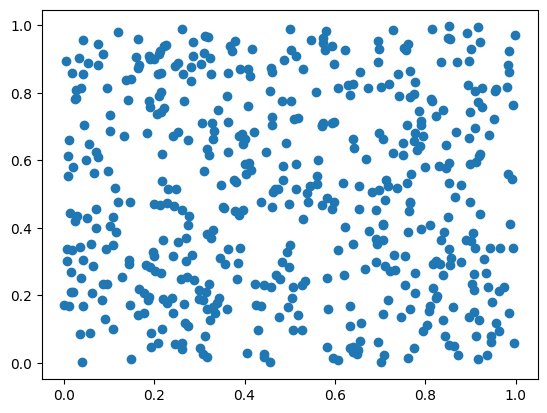

In [29]:
x = np.random.rand(500)
y = np.random.rand(500)
plt.scatter(x, y)

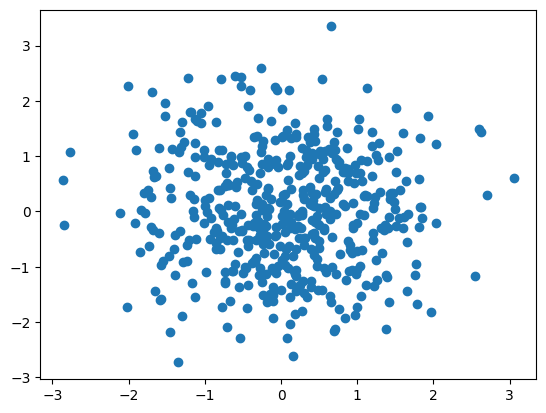

In [30]:
x = np.random.randn(500)
y = np.random.randn(500)
plt.scatter(x, y)

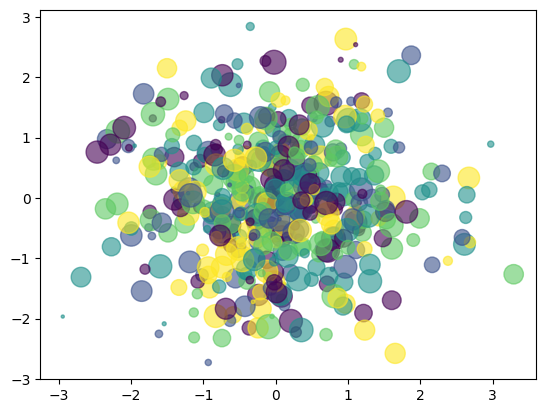

In [31]:
x = np.random.randn(500)
y = np.random.randn(500)
s = np.random.randint(5, 301, size=500)  # 隨機生成 500 個大小，範圍在 5 到 200 之間
c = np.random.randint(1, 6, 500)
plt.scatter(x, y, s=s, c=c, alpha=0.6);

## 6. 模擬真實資料

假設某數據背後的美麗函數是:

$$ y = f(x) = 1.2x + 0.8$$

一般我們實際觀察到的會是:

$$ y = f(x) + \varepsilon$$

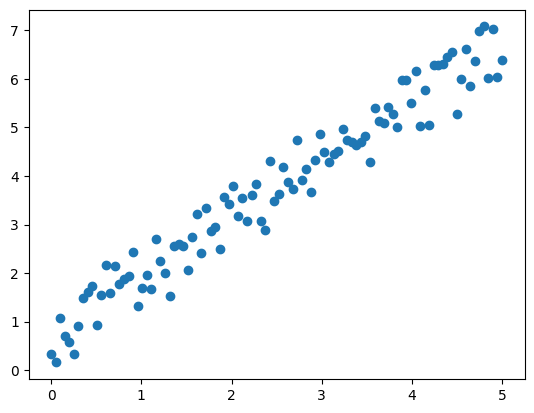

In [32]:
x = np.linspace(0, 5, 100)
y = 1.2*x + 0.8 + 0.4*np.random.randn(100)
plt.scatter(x, y);

直方圖程顯常態分佈

Text(0.5, 1.0, 'Random Data Histogram')

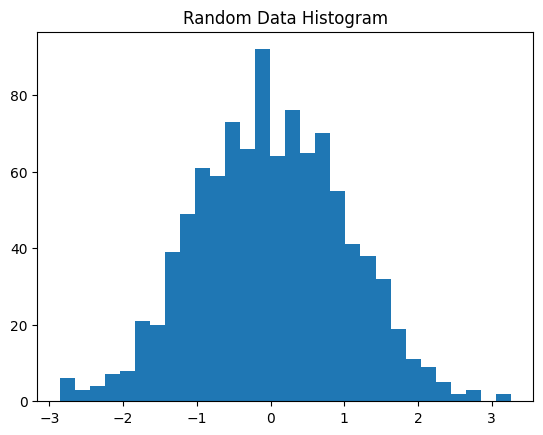

In [38]:

data = np.random.randn(1000)
plt.hist(data,bins=30)
plt.title("Random Data Histogram")



## 7. Monte Carlo：用亂數估計 π


In [39]:

n = 10000

x = np.random.rand(n)
y = np.random.rand(n)

inside = (x**2 + y**2) <= 1

pi_estimate = 4*np.sum(inside)/n
pi_estimate

np.float64(3.1604)


看看這些點長什麼樣子。


<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_812/2826585728.py:4: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Monte Carlo $\pi$")


Text(0.5, 1.0, 'Monte Carlo $\\pi$')

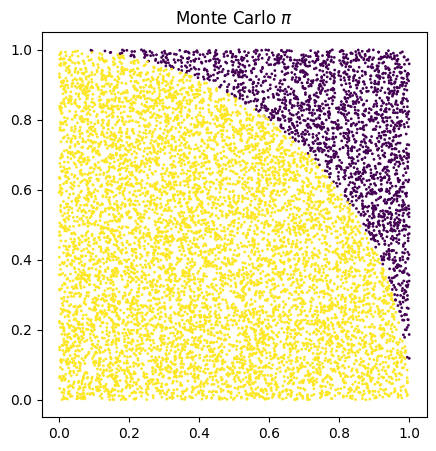

In [41]:
plt.figure(figsize=(5,5))
plt.scatter(x,y,s=1,c=inside)
plt.gca().set_aspect('equal')
plt.title("Monte Carlo $\pi$")



## 8. 亂數生成藝術


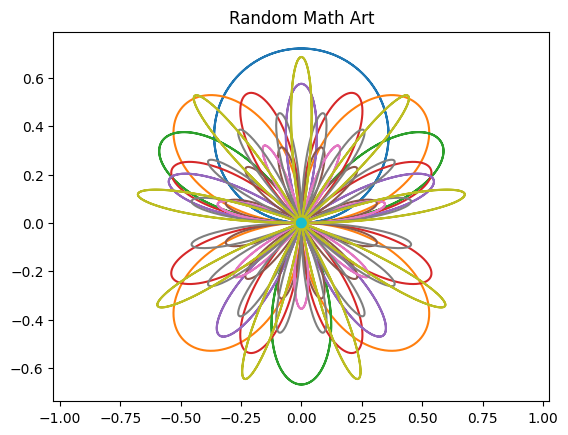

In [42]:
t = np.linspace(0,2*np.pi,1000)

for i in range(10):
    r = np.sin((i+1)*t) * np.random.rand()
    x = r*np.cos(t)
    y = r*np.sin(t)
    plt.plot(x,y)

plt.axis('equal')
plt.title("Random Math Art")
plt.show()



### 亂數顏色藝術


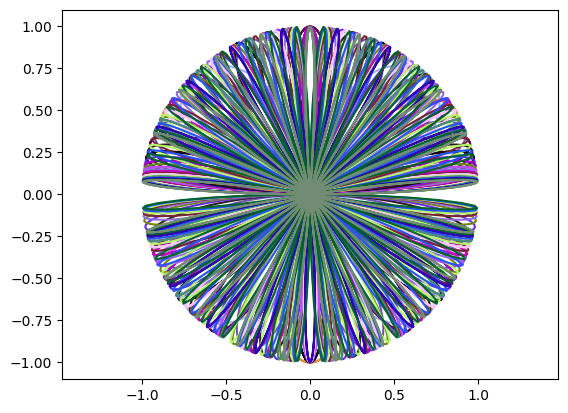

In [43]:

for i in range(20):
    t = np.linspace(0,2*np.pi,500)
    r = np.sin((i+2)*t)
    x = r*np.cos(t)
    y = r*np.sin(t)
    color = np.random.rand(3)
    plt.plot(x,y,color=color)

plt.axis('equal')
plt.show()



# 🎯 本週創作任務

請設計一個自己的 **AI 推薦系統** 或 **亂數藝術作品**。

例如：

- 🍜 午餐推薦
- 🎬 電影推薦
- 🎵 音樂推薦
- 🎮 遊戲推薦
- 🎨 隨機生成藝術

回答三個問題：

1️⃣ 你的系統推薦什麼？  
2️⃣ 你用了哪些亂數方法？  
3️⃣ AI 在哪裡幫助了你？

### 可以問 AI

- 如何做更聰明的推薦系統？
- 如何加入權重？
- 如何做隨機動畫？
